In [1]:
# Debug notebook for onset alignment
import os
import sys
from pathlib import Path


def find_project_root(markers=("py_scripts", "examples_audio", "examples_csv")) -> Path:
    current_path = Path.cwd().resolve()
    for parent in [current_path, *current_path.parents]:
        if any((parent / m).is_dir() for m in markers):
            return parent
    raise RuntimeError(f"Could not locate project root containing one of {markers} above {current_path}")


# Resolve and expose project directories
PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXAMPLES_AUDIO_DIR = PROJECT_ROOT / "examples_audio"
EXAMPLES_CSV_DIR = PROJECT_ROOT / "examples_csv"


In [2]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load CSV from URL
df_bass = pd.read_csv(str(EXAMPLES_CSV_DIR / 'tekonivel_onsets_bass.csv'))
display(df_bass)

df_hum = pd.read_csv(str(EXAMPLES_CSV_DIR / 'tekonivel_onsets_hum.csv'))
display(df_hum)

df_bdrum = pd.read_csv(str(EXAMPLES_CSV_DIR / 'tekonivel_onsets_bdrum.csv'))
display(df_bdrum)


,TIME,LABEL
0,0.691156,1.1
1,1.246259,1.2
2,1.804989,1.3
3,2.360091,1.4
4,2.915193,2.1
5,3.475737,2.2
6,4.032653,2.3
7,4.584127,2.4
8,5.146485,3.1
9,5.705215,3.2


,TIME,LABEL
0,2.371338,5.1
1,4.165079,5.2
2,5.950113,5.3
3,7.726440,5.4
4,9.512925,6.1
5,11.283447,6.2
6,13.017687,6.3


,TIME,LABEL
0,9.585488,New Point
1,10.033560,6.4
2,10.476190,7.1
3,10.926077,7.2
4,11.366893,7.3
5,11.814966,7.4
6,12.255782,8.1
7,12.703855,8.2
8,13.150113,8.3
9,13.592744,8.4


In [3]:
import numpy as np

def compute_ioi_stats(df, col='TIME'):
    onsets = df[col].to_numpy()
    ioi = np.diff(onsets)
    n_ioi = ioi.size              # total number of intervals
    return {
        'count_ioi': n_ioi,
        'min': np.min(ioi),
        'max': np.max(ioi),
        'range': np.ptp(ioi),
        'mean': np.mean(ioi)
    }

datasets = {
    'Bass': df_bass,
    'Hum': df_hum,
    'BDrum': df_bdrum
}

for name, df in datasets.items():
    stats = compute_ioi_stats(df)
    print(f"=== {name} Onset IOI stats ===")
    print(f"Count of IOI values: {stats['count_ioi']}")
    print(f"Min   = {stats['min']:.6f}")
    print(f"Max   = {stats['max']:.6f}")
    print(f"Range = {stats['range']:.6f}")
    print(f"Mean  = {stats['mean']:.6f}")
    print()


=== Bass Onset IOI stats ===
Count of IOI values: 15
Min   = 0.547846
Max   = 0.564172
Range = 0.016327
Mean  = 0.556553

=== Hum Onset IOI stats ===
Count of IOI values: 6
Min   = 1.734240
Max   = 1.793741
Range = 0.059501
Mean  = 1.774392

=== BDrum Onset IOI stats ===
Count of IOI values: 13
Min   = 0.440816
Max   = 0.449887
Range = 0.009070
Mean  = 0.445561



In [4]:
# Define the grid size in seconds
grid = 0.1114

# A list to store the new DataFrames for each instrument
all_ioi_dfs = []

for name, df in datasets.items():
    # Step 1: Calculate the IOIs
    onsets = df['TIME'].to_numpy()
    iois = np.diff(onsets)

    # Step 2: Calculate the multiplier for each IOI
    # We divide the IOI by the grid size and round to the nearest integer.
    multipliers = np.round(iois / grid).astype(int)

    # Step 3: Calculate the error for each IOI
    # Error = | Actual IOI - (Multiplier * Grid) |
    errors = np.abs(iois - (multipliers * grid))

    # Step 4: Create a new DataFrame for the current instrument
    ioi_df = pd.DataFrame({
        'IOI': iois,
        'Multiplier': multipliers,
        'Error': errors
    })
    
    # Add an 'Instrument' column to identify the source
    ioi_df['Instrument'] = name
    
    all_ioi_dfs.append(ioi_df)

# Step 5: Concatenate all the individual DataFrames into a single one
final_df = pd.concat(all_ioi_dfs, ignore_index=True)

# Reorder columns for better readability
final_df = final_df[['Instrument', 'IOI', 'Multiplier', 'Error']]

# Display the final DataFrame
display(final_df)

# You can also display statistics for the new columns
print("\n--- Error Statistics per Instrument ---")
display(final_df.groupby('Instrument')['Error'].describe())

,Instrument,IOI,Multiplier,Error
0,Bass,0.555102,5,0.001898
1,Bass,0.558730,5,0.001730
2,Bass,0.555102,5,0.001898
3,Bass,0.555102,5,0.001898
4,Bass,0.560544,5,0.003544
5,Bass,0.556916,5,0.000084
6,Bass,0.551474,5,0.005526
7,Bass,0.562358,5,0.005358
8,Bass,0.558730,5,0.001730
9,Bass,0.556916,5,0.000084



--- Error Statistics per Instrument ---


,count,mean,std,min,25%,50%,75%,max
Instrument,,,,,,,,
BDrum,13.0,0.002524,0.001473,0.000659,0.001156,0.002473,0.002970,0.004784
Bass,15.0,0.003282,0.002575,0.000084,0.001730,0.001898,0.004535,0.009154
Hum,6.0,0.014029,0.017139,0.002634,0.004582,0.008707,0.011744,0.048160


In [5]:
import numpy as np

# Assuming 'datasets' is the dictionary of your DataFrames from the original question
# datasets = {
#     'Bass': df_bass,
#     'Hum': df_hum,
#     'BDrum': df_bdrum
# }

cue_lists_np = {name: df['TIME'].to_numpy() for name, df in datasets.items()}

# Now you can access each cue list as a NumPy array
bass_onsets_np = cue_lists_np['Bass']
bdrum_onsets_np = cue_lists_np['BDrum']
hum_onsets_np = cue_lists_np['Hum']

# You can verify the type
print(f"Type of bass_onsets_np: {type(bass_onsets_np)}")
print(f"First 5 onsets for Bass: {bass_onsets_np[:5]}")

Type of bass_onsets_np: <class 'numpy.ndarray'>
First 5 onsets for Bass: [0.69115646 1.2462585  1.80498866 2.3600907  2.91519274]


Loading BokehJS ...

Loading BokehJS ...

Loaded 'C:\Users\egorp\Nextcloud\code\public_repos\beat_it\examples_audio\Tekonivel_Voimamies.aif' -> segment 0.000–15.500s of 201.024s @ 44100Hz


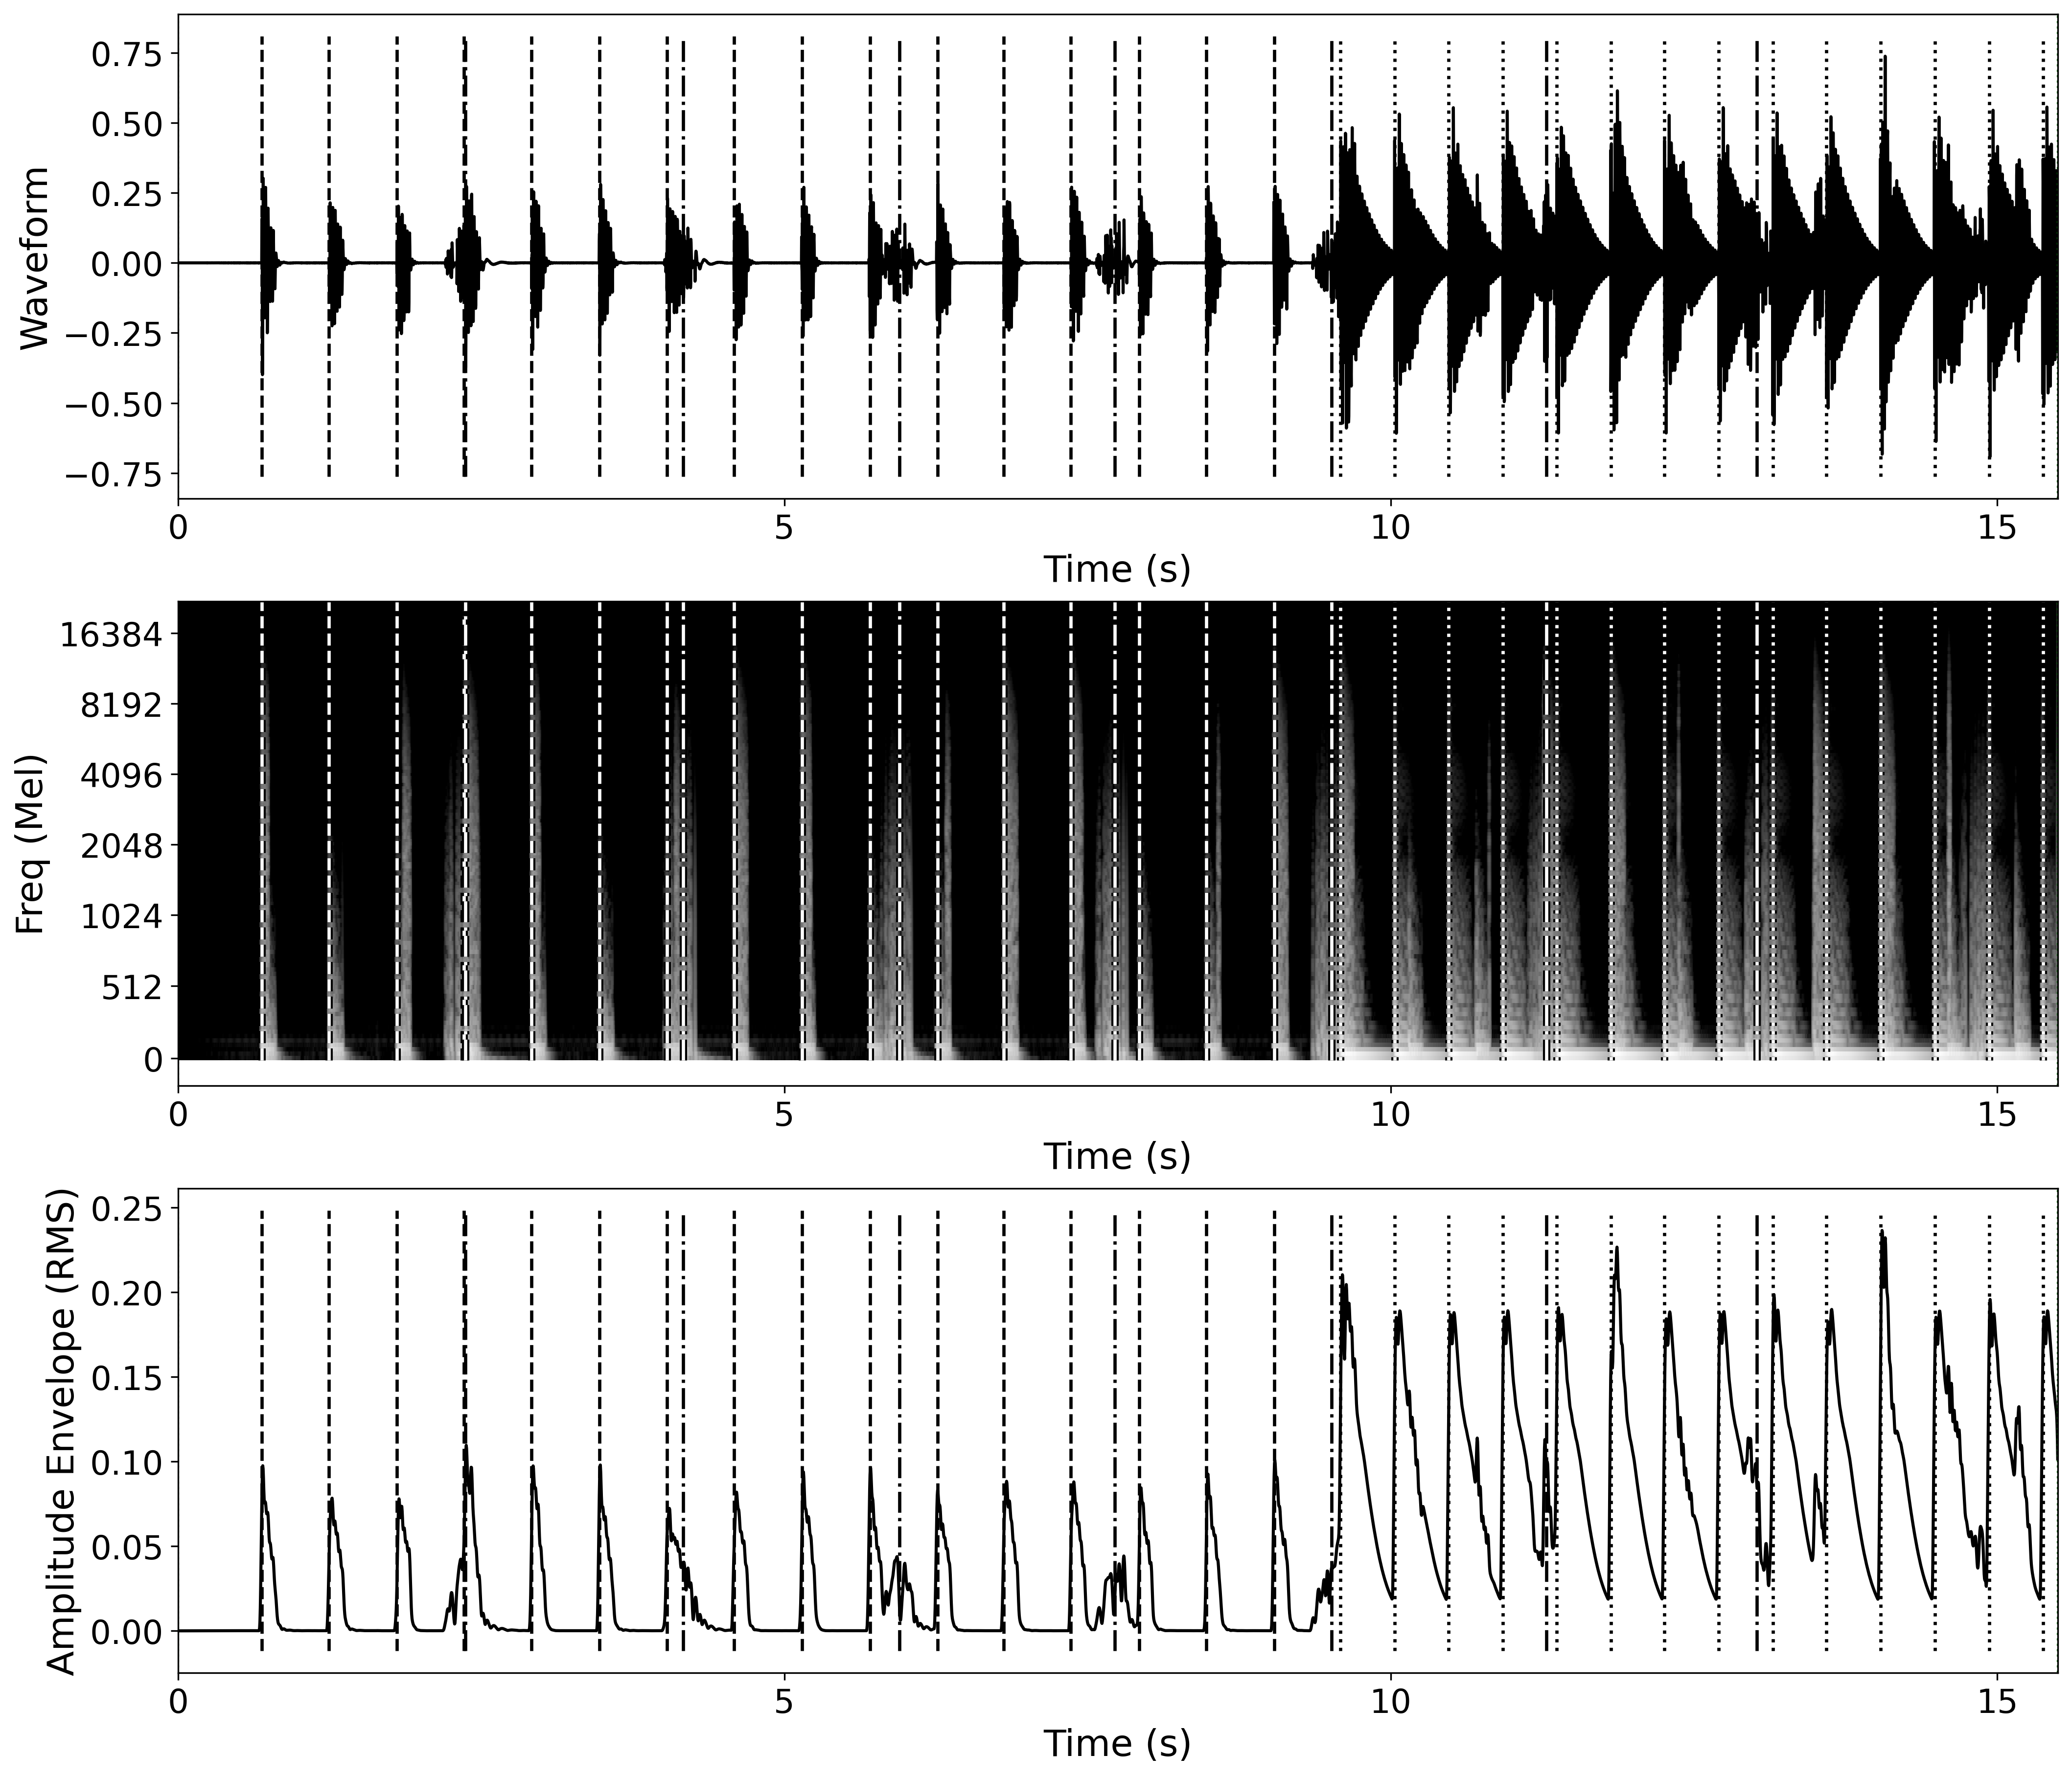

In [8]:
import numpy as np
import random
from typing import Union, List, Optional

from py_scripts.audio_visualizer import (
    load_audio, extract_features, visualize_features, parse_time_range
)
import pandas as pd

# --- BOKEH SETUP ---
from bokeh.io import output_notebook
output_notebook()
# --- END BOKEH SETUP ---


# Structure them into the dictionary for plotting
onset_times_dict = {
    "Bass": {
        "times": bass_onsets_np,
        "color": "red",
        "style": {"line_style": "dashed", "line_width": 1.6}
    },
    "Hum": {
        "times": hum_onsets_np,
        "color": "orange",
        "style": {"line_style": "dashdot", "line_width": 1.6}
    },
    "BDrum": {
        "times": bdrum_onsets_np,
        "color": "cyan",
        "style": {"line_style": "dotted", "line_width": 1.6}
    }
    # "Generated Onsets": {
    #     "times": generated_onsets,
    #     "color": "cyan",
    # }
}

# --- BOKEH SETUP ---
from bokeh.io import output_notebook
output_notebook()
# --- END BOKEH SETUP ---

# --- CONFIGURATION ---
AUDIO_PATH = str(EXAMPLES_AUDIO_DIR / 'Tekonivel_Voimamies.aif')
HOP_LENGTH = 128
N_FFT = 2048

TIME_RANGE = "00:00.000-00:15.500" 

# 1. Load the audio file
y, sr = load_audio(AUDIO_PATH, time_range=TIME_RANGE)

# 2. Define which features you want to compute and plot

# Features: 'waveform', 'stft_db', 'amplitude_envelope', 'zero_crossing_rate', 
# 'spectral_centroid', 'spectral_flux', 'high_frequency_content', 'spectral_contrast', 'cqt_flux', 
# 'melspectrogram', 'rms_low', 'rms_mid', 'rms_high'

FEATURES_TO_PLOT = ['waveform', 'melspectrogram', 'amplitude_envelope']

# 3. COMPUTE THE FEATURES from the audio signal
# This will return a dictionary like {'waveform': [...], 'stft_db': [...], ...}
feature_data = extract_features(
    y=y,
    sr=sr,
    hop_length=HOP_LENGTH,
    n_fft=N_FFT
)

# Set the backend for the inline display: 'matplotlib' or 'bokeh'
PLOTTING_BACKEND = 'matplotlib'


visualize_features(
    features=feature_data,
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=onset_times_dict,
    features_to_plot=FEATURES_TO_PLOT,
    backend=PLOTTING_BACKEND,
    time_range=TIME_RANGE,
    onsets_are_absolute=True,
    grayscale=True,
    grayscale_cmap='gray',
    show_legend=False,
    show_slice_markers=True,
    font_scale=1.8,
    dpi=300
)